<a href="https://colab.research.google.com/github/RafaelaMlucca/conformal-violence-prediction/blob/main/04_analise_comparativa_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 04 — Análise e visualizações


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

DRIVE = Path('/content/drive/MyDrive/projeto_violencia_mulher')
SAIDA = DRIVE / 'conformal_violence'
FIGURAS = SAIDA / 'figuras'
FIGURAS.mkdir(exist_ok=True)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['savefig.bbox'] = 'tight'

## 2. Carregando os resultados

In [3]:
with open(SAIDA / 'dados_conformal.pkl', 'rb') as f:
    dados = pickle.load(f)

with open(SAIDA / 'resultados_baseline.pkl', 'rb') as f:
    baseline = pickle.load(f)

with open(SAIDA / 'resultados_locart.pkl', 'rb') as f:
    locart_res = pickle.load(f)

ALVOS = dados['alvos']
feature_names = dados['feature_names']
y_test = dados['y_test']

print('Resultados carregados para:', ALVOS)

Resultados carregados para: ['y_fisic', 'y_psico', 'y_sexu']


## 3. Visualizando as árvores Locart

Para cada desfecho, plota a árvore que aprendeu a partição em subgrupos.


Como o nosso espaço de features tem 272 colunas one-hot, os nomes ficam meio
poluídos no plot. Para a versão do artigo, vou plotar com features renomeadas
para algo mais legível, mas aqui mostro a versão crua primeiro.

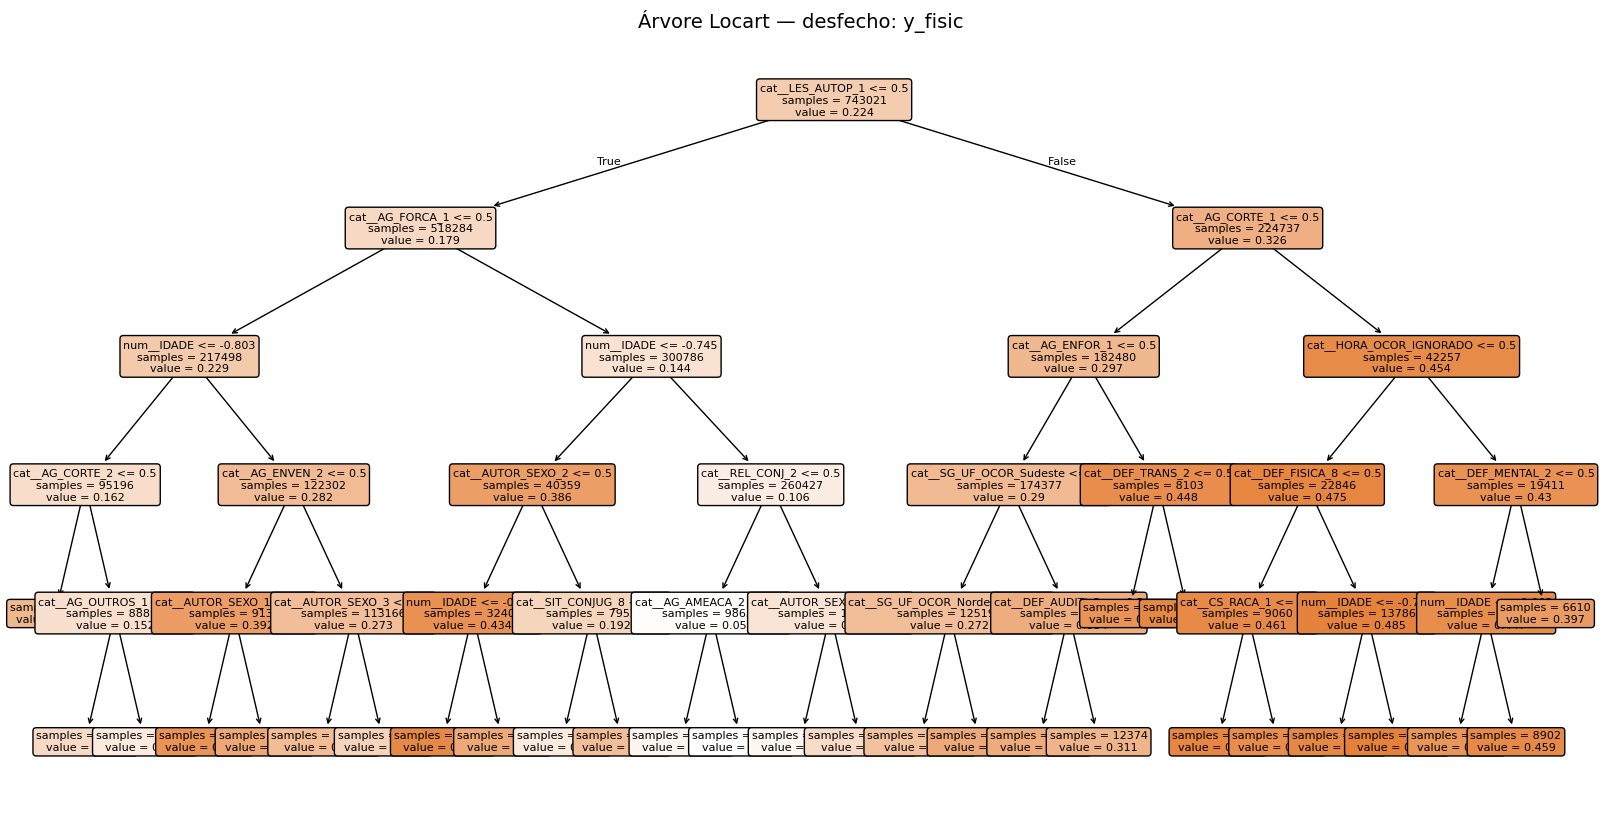

Salvo em /content/drive/MyDrive/projeto_violencia_mulher/conformal_violence/figuras/arvore_locart_y_fisic.png


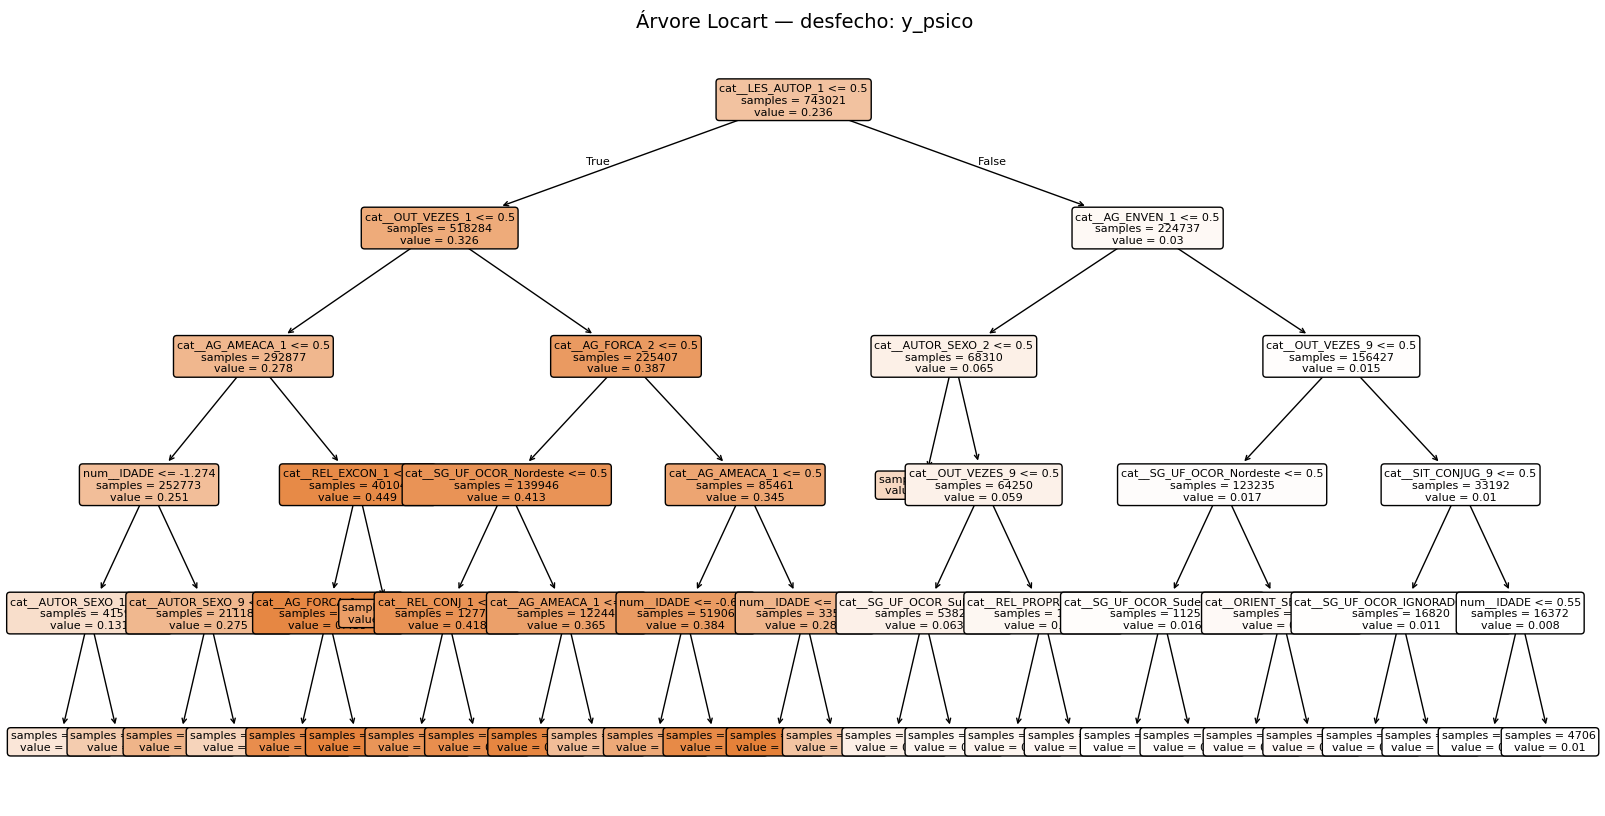

Salvo em /content/drive/MyDrive/projeto_violencia_mulher/conformal_violence/figuras/arvore_locart_y_psico.png


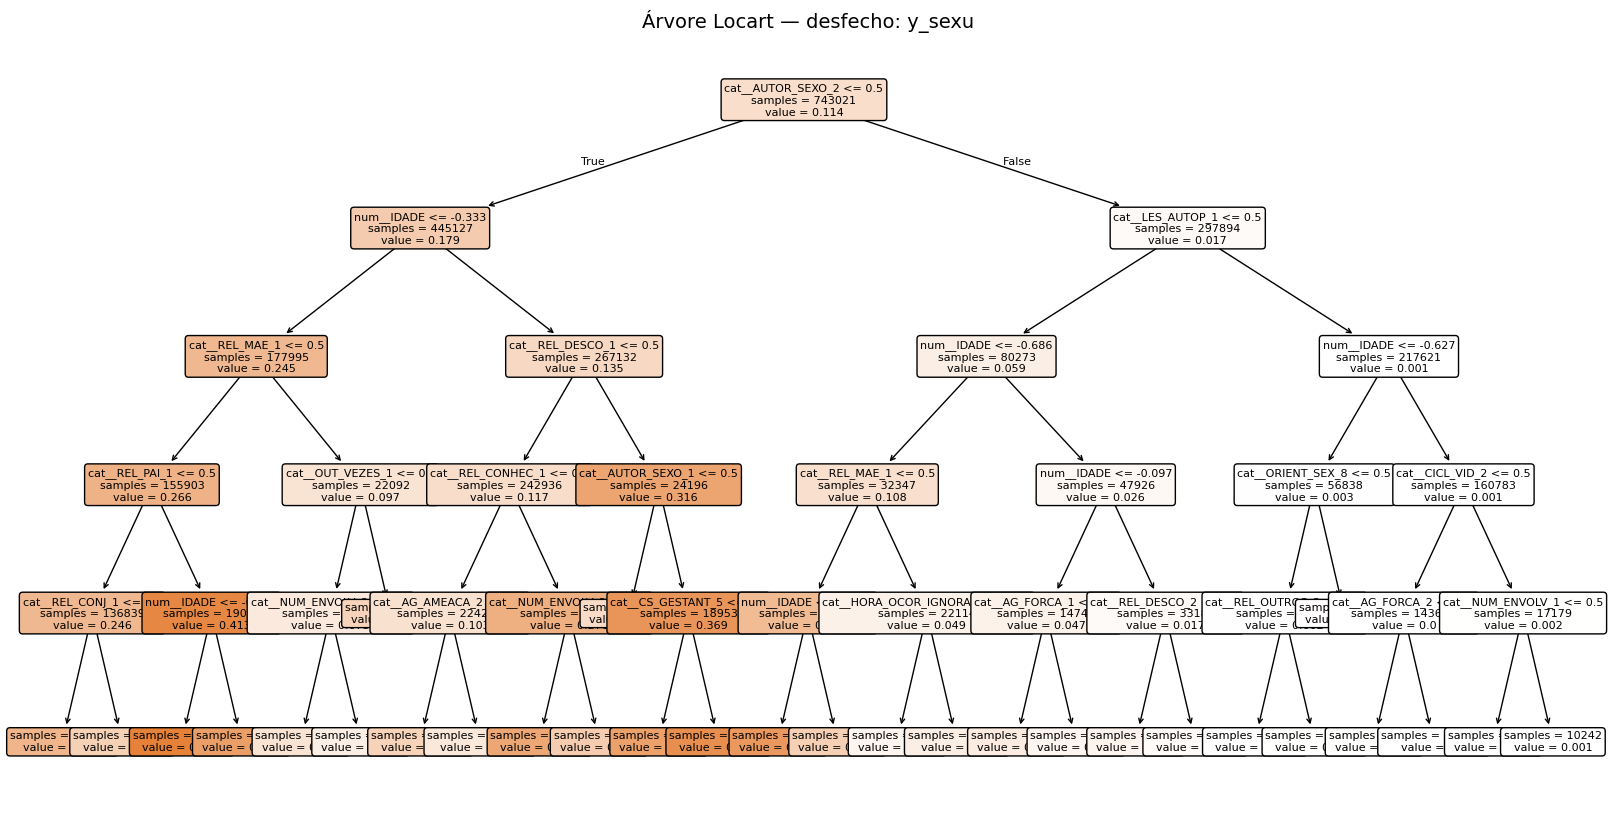

Salvo em /content/drive/MyDrive/projeto_violencia_mulher/conformal_violence/figuras/arvore_locart_y_sexu.png


In [4]:
def plotar_arvore(alvo, top_n_features=20):
    """Plota a árvore Locart de um desfecho."""
    arvore = locart_res['locart'][alvo]['locart']['arvore']

    fig, ax = plt.subplots(figsize=(20, 10))
    plot_tree(
        arvore,
        feature_names=feature_names,
        filled=True,
        rounded=True,
        fontsize=8,
        ax=ax,
        impurity=False,
    )
    plt.title(f'Árvore Locart — desfecho: {alvo}', fontsize=14)
    caminho = FIGURAS / f'arvore_locart_{alvo}.png'
    plt.savefig(caminho)
    plt.show()
    plt.close()
    print(f'Salvo em {caminho}')

# plota as 3 árvores
for alvo in ALVOS:
    plotar_arvore(alvo)

## 4. Quais features cada árvore mais usou?

A árvore do Locart escolhe as features que melhor explicam onde o modelo
principal erra. Essas features identificam os eixos de heterogeneidade do
modelo — informação valiosa para interpretar os subgrupos.

In [5]:
def importancias_arvore(alvo, top=10):
    arvore = locart_res['locart'][alvo]['locart']['arvore']
    imp = arvore.feature_importances_
    df = pd.DataFrame({
        'feature': feature_names,
        'importancia': imp,
    })
    return df.sort_values('importancia', ascending=False).head(top).reset_index(drop=True)

for alvo in ALVOS:
    print(f'\n=== Top features que dividem subgrupos — {alvo} ===')
    print(importancias_arvore(alvo).to_string(index=False))


=== Top features que dividem subgrupos — y_fisic ===
                feature  importancia
             num__IDADE     0.330684
       cat__LES_AUTOP_1     0.310892
        cat__AG_FORCA_1     0.085046
        cat__AG_CORTE_1     0.078424
        cat__REL_CONJ_2     0.046155
      cat__AUTOR_SEXO_2     0.034380
      cat__AUTOR_SEXO_1     0.027984
        cat__AG_ENFOR_1     0.017911
cat__SG_UF_OCOR_Sudeste     0.012607
        cat__AG_CORTE_2     0.011300

=== Top features que dividem subgrupos — y_psico ===
                 feature  importancia
        cat__LES_AUTOP_1     0.716703
        cat__AG_AMEACA_1     0.088166
        cat__OUT_VEZES_1     0.079525
              num__IDADE     0.065969
       cat__AUTOR_SEXO_9     0.018871
         cat__AG_FORCA_2     0.012798
         cat__AG_ENVEN_1     0.005991
       cat__AUTOR_SEXO_1     0.004425
       cat__AUTOR_SEXO_2     0.001856
cat__SG_UF_OCOR_Nordeste     0.001755

=== Top features que dividem subgrupos — y_sexu ===
          feat

## 5. Distribuição da classe verdadeira por folha

Para cada folha, mostro quantos casos positivos e negativos tem dentro dela. Os
subgrupos com prevalência muito diferente da média global são justamente os
que mais se beneficiam da personalização da cobertura.

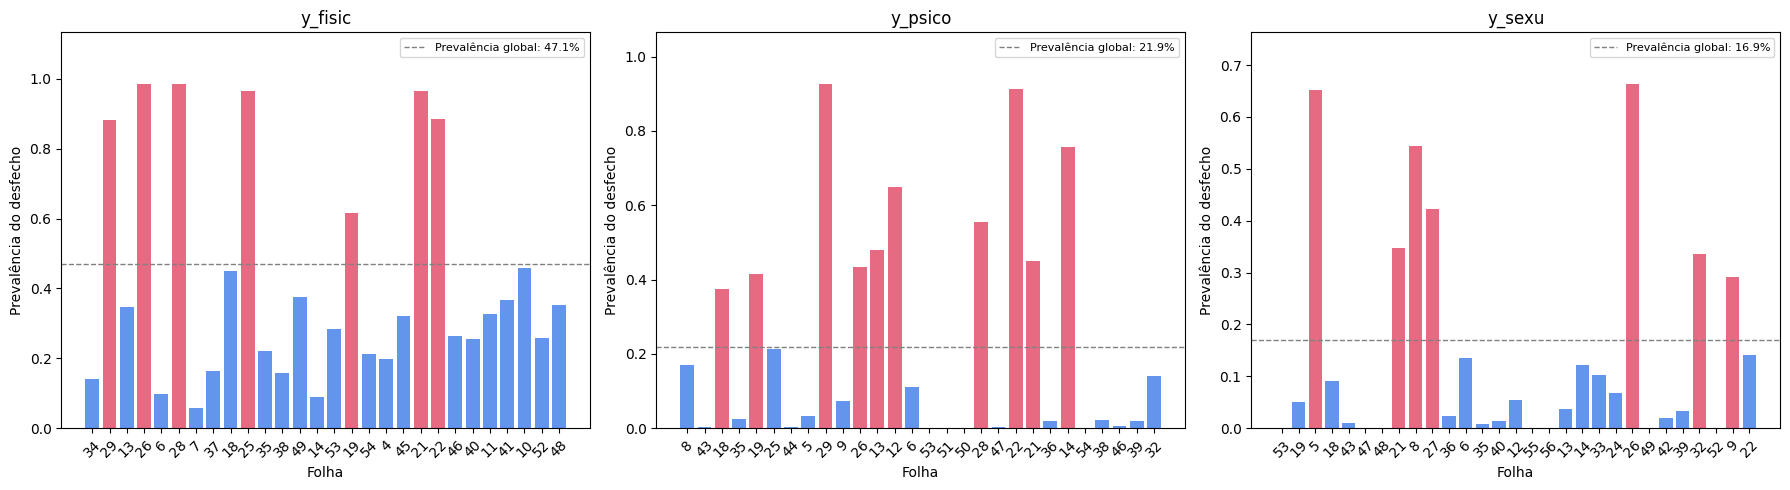

In [6]:
def composicao_por_folha(alvo):
    folhas_test = locart_res['locart'][alvo]['folhas_test']
    y_alvo = y_test[alvo].values

    linhas = []
    for f in np.unique(folhas_test):
        mask = folhas_test == f
        n = mask.sum()
        if n == 0:
            continue
        prev = y_alvo[mask].mean()
        linhas.append({
            'folha': int(f),
            'n_teste': int(n),
            'prevalencia': float(prev),
            'n_positivos': int(y_alvo[mask].sum()),
        })
    return pd.DataFrame(linhas).sort_values('n_teste', ascending=False).reset_index(drop=True)

# imprime + plota
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, alvo in zip(axes, ALVOS):
    df = composicao_por_folha(alvo)
    prev_global = y_test[alvo].mean()

    cores = ['#e76a83' if p > prev_global else '#6495ed' for p in df['prevalencia']]
    ax.bar(range(len(df)), df['prevalencia'], color=cores)
    ax.axhline(prev_global, color='gray', linestyle='--', linewidth=1,
               label=f'Prevalência global: {prev_global:.1%}')
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df['folha'].astype(str), rotation=45)
    ax.set_xlabel('Folha')
    ax.set_ylabel('Prevalência do desfecho')
    ax.set_title(alvo)
    ax.legend(fontsize=8)
    ax.set_ylim(0, max(df['prevalencia'].max() * 1.15, prev_global * 1.5))

plt.tight_layout()
plt.savefig(FIGURAS / 'prevalencia_por_folha.png')
plt.show()
plt.close()

## 6. Distribuição dos tamanhos de conjunto por folha

Stacked bar plot equivalente à Figura 5 do PersonalizedUS: mostra para cada
folha quantos casos tiveram conjunto de tamanho 0, 1 ou 2. Folhas com muitos
conjuntos de tamanho 1 são os subgrupos onde o modelo é confiante; folhas com
muitos de tamanho 2 são os subgrupos difíceis.

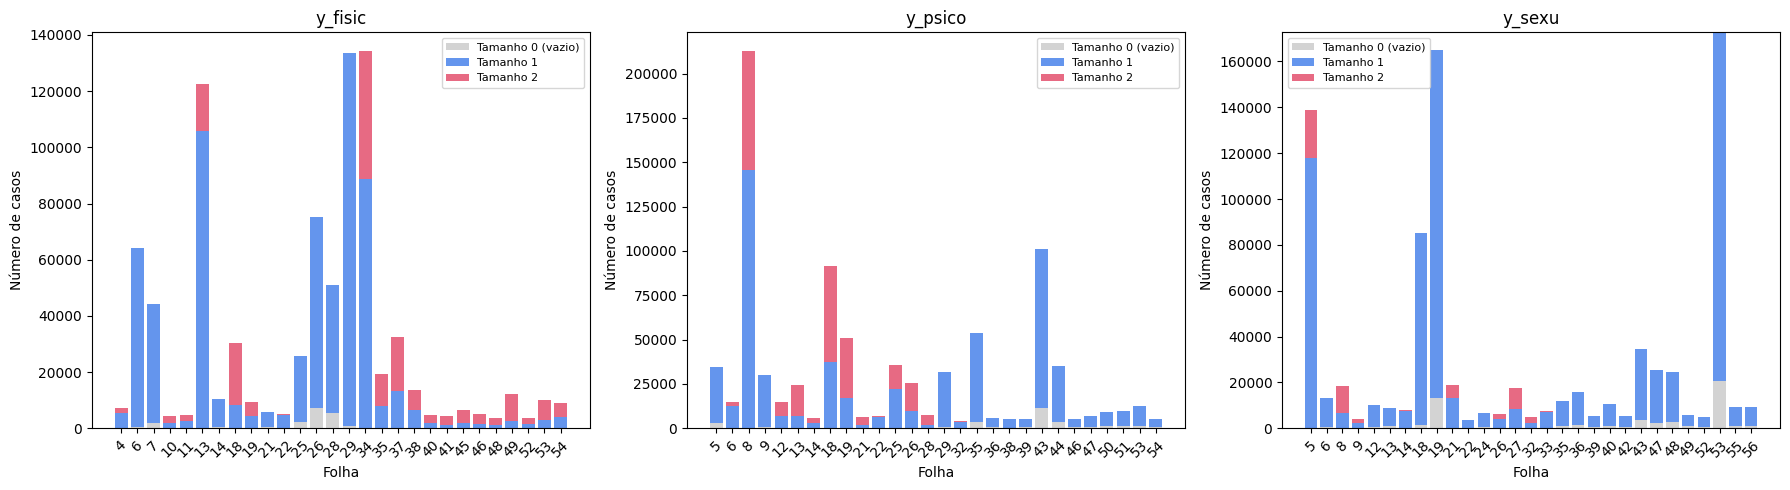

In [7]:
def tamanhos_por_folha(alvo):
    folhas_test = locart_res['locart'][alvo]['folhas_test']
    conjuntos = locart_res['locart'][alvo]['conjuntos']
    tamanhos = conjuntos.sum(axis=1)

    linhas = []
    for f in np.unique(folhas_test):
        mask = folhas_test == f
        n = mask.sum()
        if n == 0:
            continue
        t = tamanhos[mask]
        linhas.append({
            'folha': int(f),
            'n_0': int((t == 0).sum()),
            'n_1': int((t == 1).sum()),
            'n_2': int((t == 2).sum()),
        })
    return pd.DataFrame(linhas).sort_values('folha').reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, alvo in zip(axes, ALVOS):
    df = tamanhos_por_folha(alvo)
    x = np.arange(len(df))
    ax.bar(x, df['n_0'], color='#D3D3D3', label='Tamanho 0 (vazio)')
    ax.bar(x, df['n_1'], bottom=df['n_0'], color='#6495ed', label='Tamanho 1')
    ax.bar(x, df['n_2'], bottom=df['n_0'] + df['n_1'], color='#e76a83', label='Tamanho 2')
    ax.set_xticks(x)
    ax.set_xticklabels(df['folha'].astype(str), rotation=45)
    ax.set_xlabel('Folha')
    ax.set_ylabel('Número de casos')
    ax.set_title(alvo)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURAS / 'tamanhos_por_folha.png')
plt.show()
plt.close()

## 7. Tabela final para o artigo

Tabela comparativa em formato LaTeX, pronta para colar no artigo.
Equivale à Tabela 2 do PersonalizedUS.

In [8]:
tabela = locart_res['tabela_comparativa'].copy()

# arruma nomes para o artigo
tabela.columns = ['Outcome', 'Method', 'Coverage', 'Avg. Set Size',
                  'Empty (%)', 'Singletons (%)', 'Doubletons (%)']
tabela['Coverage'] = tabela['Coverage'] * 100
tabela['Empty (%)'] = tabela['Empty (%)'] * 100
tabela['Singletons (%)'] = tabela['Singletons (%)'] * 100
tabela['Doubletons (%)'] = tabela['Doubletons (%)'] * 100

# arredondamento
for col in ['Coverage', 'Avg. Set Size', 'Empty (%)', 'Singletons (%)', 'Doubletons (%)']:
    tabela[col] = tabela[col].round(2)

print(tabela.to_string(index=False))
print('\n--- LaTeX ---')
print(tabela.to_latex(index=False, float_format='%.2f'))

tabela.to_csv(SAIDA / 'tabela_comparativa_final.csv', index=False)

Outcome Method  Coverage  Avg. Set Size  Empty (%)  Singletons (%)  Doubletons (%)
y_fisic    LAC     90.65           1.12       0.00           88.17           11.83
y_fisic    APS     90.65           1.12       0.00           88.17           11.83
y_fisic Locart     90.36           1.18       2.21           77.35           20.45
y_psico    LAC     90.62           1.15       0.00           84.51           15.49
y_psico    APS     90.62           1.15       0.00           84.51           15.49
y_psico Locart     90.05           1.23       3.44           70.10           26.46
 y_sexu    LAC     89.47           0.95       4.98           95.02            0.00
 y_sexu    APS     89.47           0.95       4.98           95.02            0.00
 y_sexu Locart     89.10           1.00       6.32           87.33            6.35

--- LaTeX ---
\begin{tabular}{llrrrrr}
\toprule
Outcome & Method & Coverage & Avg. Set Size & Empty (%) & Singletons (%) & Doubletons (%) \\
\midrule
y_fisic & LAC & 90.

## 8. Tabela detalhada de cobertura local

Para cada desfecho, mostra a cobertura empírica e o tamanho médio dentro de
cada folha. Essa é a tabela que evidencia o ganho do Locart sobre métodos com
cobertura apenas marginal.

In [9]:
for alvo in ALVOS:
    df = locart_res['locart'][alvo]['tabela_folhas'].copy()
    df['cobertura'] = (df['cobertura'] * 100).round(2)
    df['tam_medio'] = df['tam_medio'].round(3)
    df['pct_unitarios'] = (df['pct_unitarios'] * 100).round(2)
    df['pct_vazios'] = (df['pct_vazios'] * 100).round(2)
    df['pct_duplos'] = (df['pct_duplos'] * 100).round(2)

    print(f'\n=== {alvo} ===')
    print(df.to_string(index=False))

    df.to_csv(SAIDA / f'cobertura_local_{alvo}.csv', index=False)


=== y_fisic ===
 folha  n_teste  cobertura  tam_medio  pct_unitarios  pct_vazios  pct_duplos
    34   134237      92.09      1.340          66.04        0.00       33.96
    29   133572      88.02      0.993          99.34        0.66        0.00
    13   122430      91.02      1.136          86.37        0.00       13.63
    26    75140      89.36      0.905          90.48        9.52        0.00
     6    64010      90.60      0.990          99.04        0.96        0.00
    28    51078      88.47      0.895          89.46       10.54        0.00
     7    44256      91.06      0.958          95.84        4.16        0.00
    37    32463      93.90      1.593          40.73        0.00       59.27
    18    30308      88.94      1.722          27.76        0.00       72.24
    25    25652      88.84      0.916          91.57        8.43        0.00
    35    19419      91.87      1.591          40.93        0.00       59.07
    38    13581      93.13      1.515          48.52       

## 9. Onde Locart faz diferença sobre MAPIE

Aqui calculo a diferença de cobertura por folha entre Locart e MAPIE APS dentro
do mesmo conjunto de teste. As folhas onde Locart melhora a cobertura indicam
exatamente onde a cobertura marginal do MAPIE estava enganando.

In [10]:
# para cada alvo, recalcula a cobertura do APS dentro das mesmas folhas do Locart
diffs = {}
for alvo in ALVOS:
    folhas_test = locart_res['locart'][alvo]['folhas_test']
    conj_locart = locart_res['locart'][alvo]['conjuntos']
    conj_aps = baseline['aps'][alvo]['conjuntos']
    y_alvo = y_test[alvo].values

    linhas = []
    for f in np.unique(folhas_test):
        mask = folhas_test == f
        if mask.sum() == 0:
            continue
        cob_locart = np.mean([conj_locart[i, y_alvo[i]] for i in np.where(mask)[0]])
        cob_aps = np.mean([conj_aps[i, y_alvo[i]] for i in np.where(mask)[0]])
        linhas.append({
            'folha': int(f),
            'n': int(mask.sum()),
            'cob_aps': float(cob_aps),
            'cob_locart': float(cob_locart),
            'diff': float(cob_locart - cob_aps),
        })
    diffs[alvo] = pd.DataFrame(linhas).sort_values('diff', ascending=False).reset_index(drop=True)

    print(f'\n=== {alvo}: diferenças Locart vs MAPIE APS por folha ===')
    print(diffs[alvo].to_string(index=False, float_format='%.4f'))


=== y_fisic: diferenças Locart vs MAPIE APS por folha ===
 folha      n  cob_aps  cob_locart    diff
    19   9288   0.7317      0.8928  0.1611
    18  30308   0.7678      0.8894  0.1217
    35  19419   0.8006      0.9187  0.1181
    37  32463   0.8484      0.9390  0.0906
    38  13581   0.8466      0.9313  0.0848
    34 134237   0.8637      0.9209  0.0573
    52   3668   0.8588      0.9133  0.0545
    40   4636   0.8596      0.9060  0.0464
    54   8940   0.8612      0.9060  0.0449
    46   5098   0.8741      0.9115  0.0375
    11   4616   0.8791      0.9151  0.0360
    41   4368   0.8832      0.9103  0.0270
     4   7392   0.8923      0.9150  0.0227
    45   6544   0.9028      0.9117  0.0089
    10   4294   0.8819      0.8829  0.0009
    53  10004   0.9139      0.9099 -0.0040
    48   3610   0.9169      0.9072 -0.0097
    13 122430   0.9261      0.9102 -0.0159
     6  64010   0.9247      0.9060 -0.0188
    22   5106   0.9072      0.8884 -0.0188
    49  12226   0.9271      0.9050 -0.

## 10. Resumo final do artigo

Conta a história em poucas linhas: quantas folhas, qual a cobertura mínima e
máxima por folha em cada método, e onde Locart fez diferença.

In [11]:
print('=' * 60)
print('RESUMO PARA O ARTIGO')
print('=' * 60)

for alvo in ALVOS:
    df_local = locart_res['locart'][alvo]['tabela_folhas']
    n_folhas = len(df_local)
    cob_min_locart = df_local['cobertura'].min()
    cob_max_locart = df_local['cobertura'].max()

    # cobertura mínima por folha no APS
    aps_por_folha = diffs[alvo].copy()
    cob_min_aps = aps_por_folha['cob_aps'].min()
    cob_max_aps = aps_por_folha['cob_aps'].max()

    print(f'\n{alvo}:')
    print(f'  Locart aprendeu {n_folhas} subgrupos.')
    print(f'  Cobertura por subgrupo: Locart {cob_min_locart:.3f}-{cob_max_locart:.3f} | APS {cob_min_aps:.3f}-{cob_max_aps:.3f}')

    # folha onde Locart mais melhorou
    melhor = aps_por_folha.iloc[0]
    print(f'  Maior melhora em uma folha: +{melhor["diff"]:.3f} (folha {melhor["folha"]}, n={melhor["n"]})')

RESUMO PARA O ARTIGO

y_fisic:
  Locart aprendeu 28 subgrupos.
  Cobertura por subgrupo: Locart 0.880-0.939 | APS 0.732-0.986
  Maior melhora em uma folha: +0.161 (folha 19.0, n=9288.0)

y_psico:
  Locart aprendeu 28 subgrupos.
  Cobertura por subgrupo: Locart 0.870-0.923 | APS 0.824-1.000
  Maior melhora em uma folha: +0.095 (folha 28.0, n=7386.0)

y_sexu:
  Locart aprendeu 29 subgrupos.
  Cobertura por subgrupo: Locart 0.869-0.914 | APS 0.447-1.000
  Maior melhora em uma folha: +0.436 (folha 8.0, n=18326.0)
